# Select Best Disentanglement Methods

This notebook systematically selects the top-2 disentanglement methods from all nonlinear-noise experiment results on `halfcheetah-medium-v2`.

## Analysis pipeline
- **Cell 1**: Imports and project root setup
- **Cell 2**: Runtime parameters
- **Cell 3**: Load and validate data
- **Step 1**: Global mean ranking — average normalized score across all 16 (dim, scale) configs
- **Step 2**: Hard-condition robustness — performance on the 4 hardest configs (large dim + large scale)
- **Step 3**: Performance degradation curve — score drop as noise scale increases
- **Step 4**: Win rate vs. plain baseline — fraction of configs where method beats the baseline
- **Step 5**: Score heatmap — full (dim × scale) breakdown per method
- **Step 6**: Composite ranking and final verdict

In [38]:
from pathlib import Path
import json
import re
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "results").exists():
            return candidate
    raise RuntimeError("Could not locate project root.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import RAW_METRICS_DIR, FIGURES_METHOD_SELECTION_DIR, TABLES_METHOD_SELECTION_DIR

sns.set_theme(style="whitegrid", font_scale=1.15)
print(f"[INFO] PROJECT_ROOT = {PROJECT_ROOT}")
print(f"[INFO] RAW_METRICS_DIR = {RAW_METRICS_DIR}")

[INFO] PROJECT_ROOT = /home/wyuhan/projects/robust-offline-rl-disentanglement
[INFO] RAW_METRICS_DIR = /home/wyuhan/projects/robust-offline-rl-disentanglement/results/raw_metrics


In [39]:
# ── Per-environment configurations ───────────────────────────────────────────
ENV_CONFIGS = {
    "halfcheetah-medium-v2": {
        "dims":              [4, 8, 13, 17],
        "scales":            [0.5, 1.0, 1.5, 2.0],
        "seeds":             [2],
        "hard_dim_thresh":   13,
        "hard_scale_thresh": 1.5,
        "disentangle_methods": [
            "disentangled_cov",
            "disentangled_hsic",
            "disentangled_barlow",
            "disentangled_dcor",
            "disentangled_infonce",
            "disentangled_l1",
        ],
    },
    "hopper-medium-v2": {
        "dims":              [3, 6, 8, 11],
        "scales":            [0.5, 1.0, 1.5, 2.0],
        "seeds":             [1, 2, 3],
        "hard_dim_thresh":   8,
        "hard_scale_thresh": 1.5,
        "disentangle_methods": [
            "disentangled_hsic",
            "disentangled_barlow",
            "disentangled_dcor",
        ],
    },
    "ant-medium-v2": {
        "dims":              [28, 56, 83, 111],
        "scales":            [0.5, 1.0, 1.5, 2.0],
        "seeds":             [1, 2, 3],
        "hard_dim_thresh":   83,
        "hard_scale_thresh": 1.5,
        "disentangle_methods": [
            "disentangled_hsic",
            "disentangled_barlow",
            "disentangled_dcor",
        ],
    },
    "walker2d-medium-v2": {
        "dims":              [4, 8, 13, 17],
        "scales":            [0.5, 1.0, 1.5, 2.0],
        "seeds":             [1, 2, 3],
        "hard_dim_thresh":   13,
        "hard_scale_thresh": 1.5,
        "disentangle_methods": [
            "disentangled_hsic",
            "disentangled_barlow",
            "disentangled_dcor",
        ],
    },
}

# ── 只需改这一行来切换环境 ──────────────────────────────────────────────────
TARGET_ENV  = "ant-medium-v2"
TARGET_TYPE = "nonlinear"

# 自动从配置中派生，无需手动修改
_cfg              = ENV_CONFIGS[TARGET_ENV]
TARGET_DIMS       = _cfg["dims"]
TARGET_SCALES     = _cfg["scales"]
TARGET_SEEDS      = _cfg["seeds"]
HARD_DIM_THRESH   = _cfg["hard_dim_thresh"]
HARD_SCALE_THRESH = _cfg["hard_scale_thresh"]
DISENTANGLE_METHODS = _cfg["disentangle_methods"]

BASELINE_METHODS = ["plain", "raw_noisy", "true_only"]
ALL_METHODS = DISENTANGLE_METHODS + BASELINE_METHODS

SAVE_FIGURES = True
SAVE_TABLES  = True

FIGURE_OUT_DIR = FIGURES_METHOD_SELECTION_DIR / TARGET_ENV
TABLE_OUT_DIR  = TABLES_METHOD_SELECTION_DIR  / TARGET_ENV
FIGURE_OUT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Display labels and color palette
METHOD_LABELS = {
    "true_only":            "No Noise (Oracle)",
    "plain":                "Plain Encoder",
    "raw_noisy":            "Raw Noisy",
    "disentangled_cov":     "Covariance",
    "disentangled_hsic":    "HSIC",
    "disentangled_barlow":  "Barlow",
    "disentangled_dcor":    "dCor",
    "disentangled_infonce": "InfoNCE",
    "disentangled_l1":      "L1",
}

PALETTE = {
    "No Noise (Oracle)": "#2c3e50",
    "Plain Encoder":     "#3498db",
    "Raw Noisy":         "#bdc3c7",
    "Covariance":        "#e74c3c",
    "HSIC":              "#d35400",
    "Barlow":            "#f39c12",
    "dCor":              "#8e44ad",
    "InfoNCE":           "#e84393",
    "L1":                "#00cec9",
}

print(f"[INFO] TARGET_ENV          = {TARGET_ENV}")
print(f"[INFO] TARGET_DIMS         = {TARGET_DIMS}")
print(f"[INFO] TARGET_SCALES       = {TARGET_SCALES}")
print(f"[INFO] TARGET_SEEDS        = {TARGET_SEEDS}")
print(f"[INFO] HARD thresh         = dim>={HARD_DIM_THRESH}, scale>={HARD_SCALE_THRESH}")
print(f"[INFO] DISENTANGLE_METHODS = {DISENTANGLE_METHODS}")
print("[INFO] Parameters set.")

[INFO] TARGET_ENV          = ant-medium-v2
[INFO] TARGET_DIMS         = [28, 56, 83, 111]
[INFO] TARGET_SCALES       = [0.5, 1.0, 1.5, 2.0]
[INFO] TARGET_SEEDS        = [1, 2, 3]
[INFO] HARD thresh         = dim>=83, scale>=1.5
[INFO] DISENTANGLE_METHODS = ['disentangled_hsic', 'disentangled_barlow', 'disentangled_dcor']
[INFO] Parameters set.


In [40]:
# ── Load experiment results ──────────────────────────────────────────────────
def load_records(raw_metrics_dir, all_methods, target_env,
                 target_dims, target_scales, target_type, target_seeds):
    """Walk raw_metrics_dir and collect all matching metrics.json entries."""
    records = []
    oracle_scores = []

    for json_path in raw_metrics_dir.rglob("*.json"):
        try:
            data = json.loads(json_path.read_text(encoding="utf-8"))
        except Exception:
            continue

        score = data.get("normalized_score")
        if score is None:
            continue

        path_str = str(json_path).replace("\\", "/")
        method = data.get("method") or data.get("group") or ""
        if not method:
            for m in all_methods:
                if f"/{m}/" in path_str:
                    method = m
                    break
        if method not in all_methods:
            continue

        env = data.get("env") or data.get("env_name") or ""
        if not env:
            for part in json_path.parts:
                if part == target_env:
                    env = part
                    break
        if env != target_env:
            continue

        seed = data.get("seed")
        if seed is None:
            m = re.search(r"seed_?(\d+)", path_str, re.IGNORECASE)
            seed = int(m.group(1)) if m else None
        else:
            seed = int(seed)

        if method == "true_only":
            oracle_scores.append(float(score))
            continue

        noise_dim   = data.get("noise_dim")
        noise_scale = data.get("noise_scale")
        noise_type  = data.get("noise_type")
        if noise_dim is None or noise_scale is None or noise_type is None:
            continue

        if noise_type  != target_type:          continue
        if int(noise_dim)    not in target_dims:   continue
        if float(noise_scale) not in target_scales: continue
        if seed is None or int(seed) not in target_seeds: continue

        records.append({
            "Method":  method,
            "Label":   METHOD_LABELS.get(method, method),
            "Dim":     int(noise_dim),
            "Scale":   float(noise_scale),
            "Type":    noise_type,
            "Seed":    int(seed),
            "Score":   float(score),
        })

    df = pd.DataFrame(records)
    oracle_mean = float(np.mean(oracle_scores)) if oracle_scores else None
    return df, oracle_mean


df, oracle_mean = load_records(
    RAW_METRICS_DIR, ALL_METHODS, TARGET_ENV,
    TARGET_DIMS, TARGET_SCALES, TARGET_TYPE, TARGET_SEEDS,
)

print(f"[INFO] Loaded {len(df)} records.")
print(f"[INFO] Methods found : {sorted(df['Method'].unique())}")
print(f"[INFO] Oracle (true_only) mean score = {oracle_mean:.3f}" if oracle_mean else "[WARN] No oracle records found.")
df.head(10)

[INFO] Loaded 240 records.
[INFO] Methods found : ['disentangled_barlow', 'disentangled_dcor', 'disentangled_hsic', 'plain', 'raw_noisy']
[INFO] Oracle (true_only) mean score = 83.883


,Method,Label,Dim,Scale,Type,Seed,Score
0,disentangled_dcor,dCor,56,1.5,nonlinear,1,54.221241
1,disentangled_dcor,dCor,56,1.5,nonlinear,3,51.882739
2,disentangled_dcor,dCor,56,1.5,nonlinear,2,53.614295
3,disentangled_dcor,dCor,83,1.0,nonlinear,1,69.467463
4,disentangled_dcor,dCor,83,1.0,nonlinear,3,31.381020
5,disentangled_dcor,dCor,83,1.0,nonlinear,2,57.739347
6,disentangled_dcor,dCor,111,1.0,nonlinear,1,53.704787
7,disentangled_dcor,dCor,111,1.0,nonlinear,3,63.754106
8,disentangled_dcor,dCor,111,1.0,nonlinear,2,66.827133
9,disentangled_dcor,dCor,28,1.0,nonlinear,1,83.408486


## Step 1 — Global mean ranking

Average normalized score across **all 16 (dim, scale) configurations**.
This measures overall expected performance regardless of the specific noise setting.

Global mean normalized score (all 16 configs):
            Label  GlobalMean
No Noise (Oracle)   83.883486
        Raw Noisy   61.165819
             HSIC   58.158691
    Plain Encoder   57.612154
             dCor   56.029023
           Barlow   30.534425
[INFO] Saved: /home/wyuhan/projects/robust-offline-rl-disentanglement/results/method_selection/figures/ant-medium-v2/step1_global_mean.png


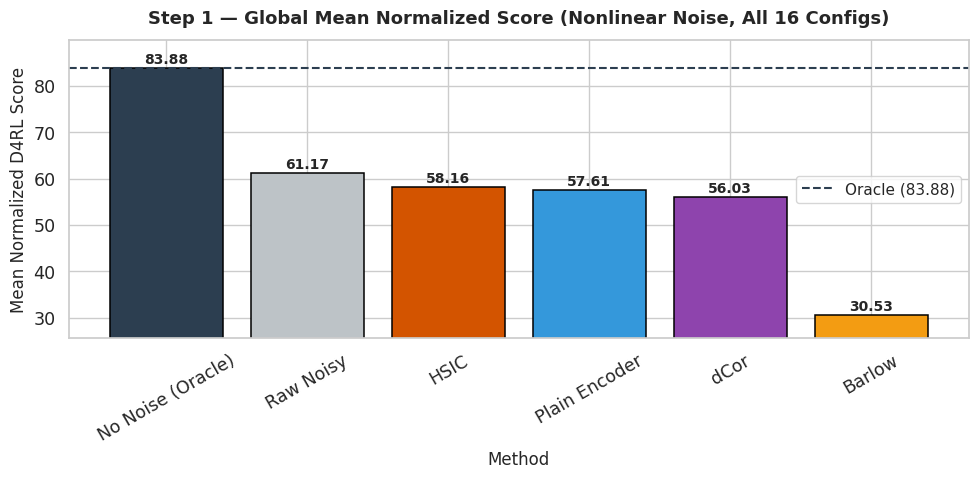

In [41]:
# ── Global mean per method ───────────────────────────────────────────────────
global_mean = (
    df.groupby("Method")["Score"]
    .mean()
    .rename("GlobalMean")
    .reset_index()
)
global_mean["Label"] = global_mean["Method"].map(METHOD_LABELS)
global_mean = global_mean.sort_values("GlobalMean", ascending=False).reset_index(drop=True)

if oracle_mean is not None:
    oracle_row = pd.DataFrame([{
        "Method": "true_only", "Label": "No Noise (Oracle)", "GlobalMean": oracle_mean
    }])
    global_mean = pd.concat([oracle_row, global_mean], ignore_index=True)

print("Global mean normalized score (all 16 configs):")
print(global_mean[["Label", "GlobalMean"]].to_string(index=False))

# ── Bar chart ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

colors = [PALETTE.get(lbl, "#aaaaaa") for lbl in global_mean["Label"]]
bars = ax.bar(global_mean["Label"], global_mean["GlobalMean"], color=colors,
              edgecolor="black", linewidth=1.1)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3, f"{h:.2f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

if oracle_mean is not None:
    ax.axhline(oracle_mean, color="#2c3e50", linestyle="--", linewidth=1.5,
               label=f"Oracle ({oracle_mean:.2f})")
    ax.legend(fontsize=11)

ax.set_title("Step 1 — Global Mean Normalized Score (Nonlinear Noise, All 16 Configs)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Mean Normalized D4RL Score", fontsize=12)
ax.set_xlabel("Method", fontsize=12)
ax.tick_params(axis="x", rotation=30)
ymin = max(0, global_mean["GlobalMean"].min() - 5)
ax.set_ylim(ymin, global_mean["GlobalMean"].max() + 6)
plt.tight_layout()

if SAVE_FIGURES:
    out = FIGURE_OUT_DIR / "step1_global_mean.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"[INFO] Saved: {out}")
plt.show()

## Step 2 — Hard-condition robustness

Average score on the **4 hardest configurations** only (`dim ≥ 13` AND `scale ≥ 1.5`).  
A method that leads here is genuinely robust to severe nonlinear corruption.

Hard configs (dim >= 83, scale >= 1.5): [(83, 1.5), (83, 2.0), (111, 1.5), (111, 2.0)]

Hard-condition mean (4 hardest configs):
        Label  HardMean
    Raw Noisy 40.463828
         dCor 33.032152
         HSIC 31.664815
Plain Encoder 30.962000
       Barlow 15.011729
[INFO] Saved: /home/wyuhan/projects/robust-offline-rl-disentanglement/results/method_selection/figures/ant-medium-v2/step2_hard_condition.png


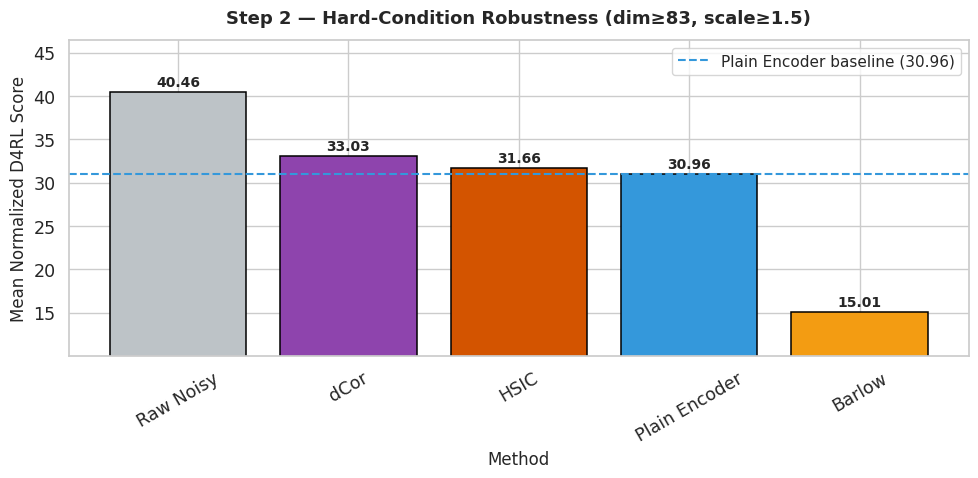

In [42]:
# ── Hard-condition mean ───────────────────────────────────────────────────────
df_hard = df[(df["Dim"] >= HARD_DIM_THRESH) & (df["Scale"] >= HARD_SCALE_THRESH)].copy()
hard_configs = [(d, s) for d in TARGET_DIMS if d >= HARD_DIM_THRESH
                        for s in TARGET_SCALES if s >= HARD_SCALE_THRESH]
print(f"Hard configs (dim >= {HARD_DIM_THRESH}, scale >= {HARD_SCALE_THRESH}): {hard_configs}")

hard_mean = (
    df_hard.groupby("Method")["Score"]
    .mean()
    .rename("HardMean")
    .reset_index()
)
hard_mean["Label"] = hard_mean["Method"].map(METHOD_LABELS)
hard_mean = hard_mean.sort_values("HardMean", ascending=False).reset_index(drop=True)

print("\nHard-condition mean (4 hardest configs):")
print(hard_mean[["Label", "HardMean"]].to_string(index=False))

# ── Bar chart ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

colors = [PALETTE.get(lbl, "#aaaaaa") for lbl in hard_mean["Label"]]
bars = ax.bar(hard_mean["Label"], hard_mean["HardMean"], color=colors,
              edgecolor="black", linewidth=1.1)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3, f"{h:.2f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

plain_hard = hard_mean.loc[hard_mean["Method"] == "plain", "HardMean"]
if not plain_hard.empty:
    ax.axhline(float(plain_hard.iloc[0]), color="#3498db", linestyle="--", linewidth=1.5,
               label=f"Plain Encoder baseline ({float(plain_hard.iloc[0]):.2f})")
    ax.legend(fontsize=11)

ax.set_title(f"Step 2 — Hard-Condition Robustness (dim≥{HARD_DIM_THRESH}, scale≥{HARD_SCALE_THRESH})",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Mean Normalized D4RL Score", fontsize=12)
ax.set_xlabel("Method", fontsize=12)
ax.tick_params(axis="x", rotation=30)
ymin = max(0, hard_mean["HardMean"].min() - 5)
ax.set_ylim(ymin, hard_mean["HardMean"].max() + 6)
plt.tight_layout()

if SAVE_FIGURES:
    out = FIGURE_OUT_DIR / "step2_hard_condition.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"[INFO] Saved: {out}")
plt.show()

## Step 3 — Performance degradation curve

For each method, plot **score vs. noise scale** (averaged over all dims).  
A flatter curve indicates the method degrades more gracefully as noise intensifies.

Degradation from scale=0.5 to scale=2.0 (smaller drop = more robust):
        Label      Drop   DropPct
       Barlow 15.465527 42.670567
         dCor 30.748863 43.593558
    Raw Noisy 34.820650 44.685419
         HSIC 36.962504 48.106539
Plain Encoder 40.418812 51.362837
[INFO] Saved: /home/wyuhan/projects/robust-offline-rl-disentanglement/results/method_selection/figures/ant-medium-v2/step3_degradation_curve.png


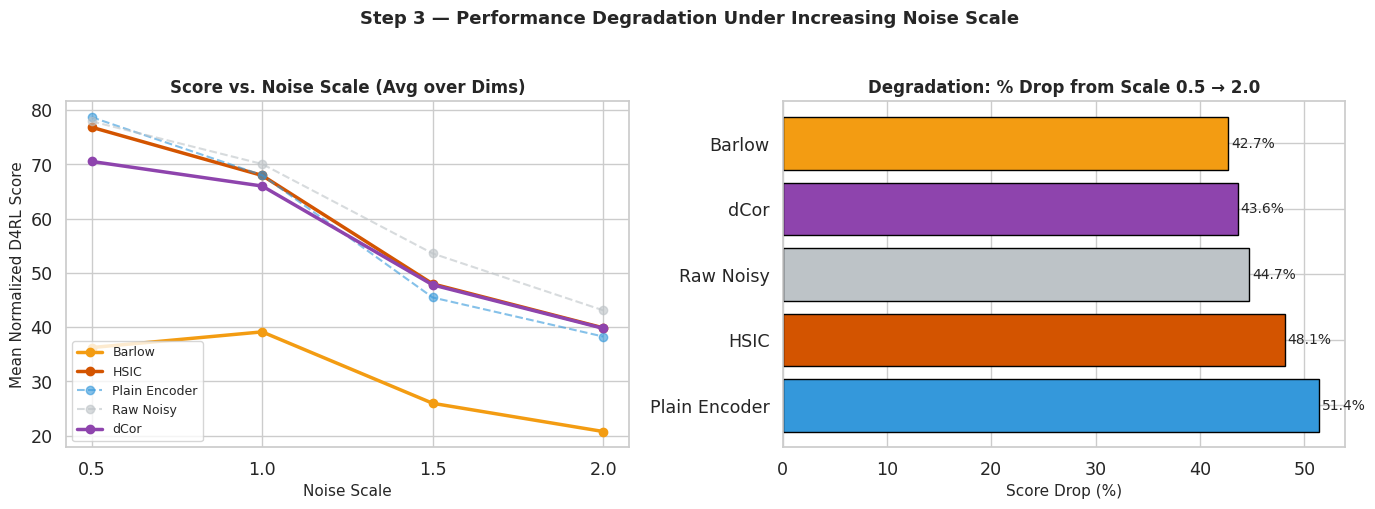

In [43]:
# ── Degradation curve ─────────────────────────────────────────────────────────
deg_df = (
    df.groupby(["Method", "Label", "Scale"])["Score"]
    .mean()
    .reset_index()
    .rename(columns={"Score": "MeanScore"})
)

# Compute drop: score at scale=2.0 minus score at scale=0.5 (negative = degradation)
score_05 = deg_df[deg_df["Scale"] == 0.5].set_index("Method")["MeanScore"]
score_20 = deg_df[deg_df["Scale"] == 2.0].set_index("Method")["MeanScore"]
drop_df = (score_05 - score_20).rename("Drop").reset_index()
drop_df["Label"] = drop_df["Method"].map(METHOD_LABELS)
drop_df["DropPct"] = drop_df["Drop"] / score_05.reindex(drop_df["Method"]).values * 100
drop_df = drop_df.sort_values("DropPct").reset_index(drop=True)  # lower % drop = better

print("Degradation from scale=0.5 to scale=2.0 (smaller drop = more robust):")
print(drop_df[["Label", "Drop", "DropPct"]].to_string(index=False))

# ── Line plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: score vs scale curves
ax = axes[0]
disentangle_labels = [METHOD_LABELS[m] for m in DISENTANGLE_METHODS]
baseline_labels    = [METHOD_LABELS[m] for m in ["plain", "raw_noisy"]]

for _, grp in deg_df.groupby("Label"):
    lbl = grp["Label"].iloc[0]
    color = PALETTE.get(lbl, "#aaaaaa")
    lw = 2.5 if lbl in disentangle_labels else 1.5
    ls = "-" if lbl in disentangle_labels else "--"
    alpha = 1.0 if lbl in disentangle_labels else 0.6
    grp_sorted = grp.sort_values("Scale")
    ax.plot(grp_sorted["Scale"], grp_sorted["MeanScore"],
            marker="o", label=lbl, color=color,
            linewidth=lw, linestyle=ls, alpha=alpha)

ax.set_title("Score vs. Noise Scale (Avg over Dims)", fontsize=12, fontweight="bold")
ax.set_xlabel("Noise Scale", fontsize=11)
ax.set_ylabel("Mean Normalized D4RL Score", fontsize=11)
ax.xaxis.set_major_locator(mticker.FixedLocator(TARGET_SCALES))
ax.legend(fontsize=9, loc="lower left")

# Right: drop percentage bar chart
ax2 = axes[1]
colors2 = [PALETTE.get(lbl, "#aaaaaa") for lbl in drop_df["Label"]]
bars2 = ax2.barh(drop_df["Label"], drop_df["DropPct"], color=colors2,
                 edgecolor="black", linewidth=1.0)
for bar in bars2:
    w = bar.get_width()
    ax2.text(w + 0.3, bar.get_y() + bar.get_height() / 2,
             f"{w:.1f}%", va="center", fontsize=10)

ax2.set_title("Degradation: % Drop from Scale 0.5 → 2.0", fontsize=12, fontweight="bold")
ax2.set_xlabel("Score Drop (%)", fontsize=11)
ax2.set_ylabel("")
ax2.invert_yaxis()  # best (lowest drop) on top

plt.suptitle("Step 3 — Performance Degradation Under Increasing Noise Scale",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()

if SAVE_FIGURES:
    out = FIGURE_OUT_DIR / "step3_degradation_curve.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"[INFO] Saved: {out}")
plt.show()

## Step 4 — Win rate vs. both baselines

For each of the 16 (dim, scale) configurations, a disentanglement method **wins** only if its score
strictly exceeds **both** the plain encoder and raw_noisy baseline.  
**Win rate = fraction of configs where method beats both baselines simultaneously.**  
This is a stricter criterion that confirms the method adds value beyond simply ignoring noise.

Win rate — beats BOTH plain encoder AND raw_noisy:
 Label  Wins  Total  WinRate  AvgMarginPlain  AvgMarginRaw
  HSIC     6     16   0.3750        0.546537     -3.007128
  dCor     3     16   0.1875       -1.583132     -5.136797
Barlow     0     16   0.0000      -27.077729    -30.631394
[INFO] Saved: /home/wyuhan/projects/robust-offline-rl-disentanglement/results/method_selection/figures/ant-medium-v2/step4_win_rate.png


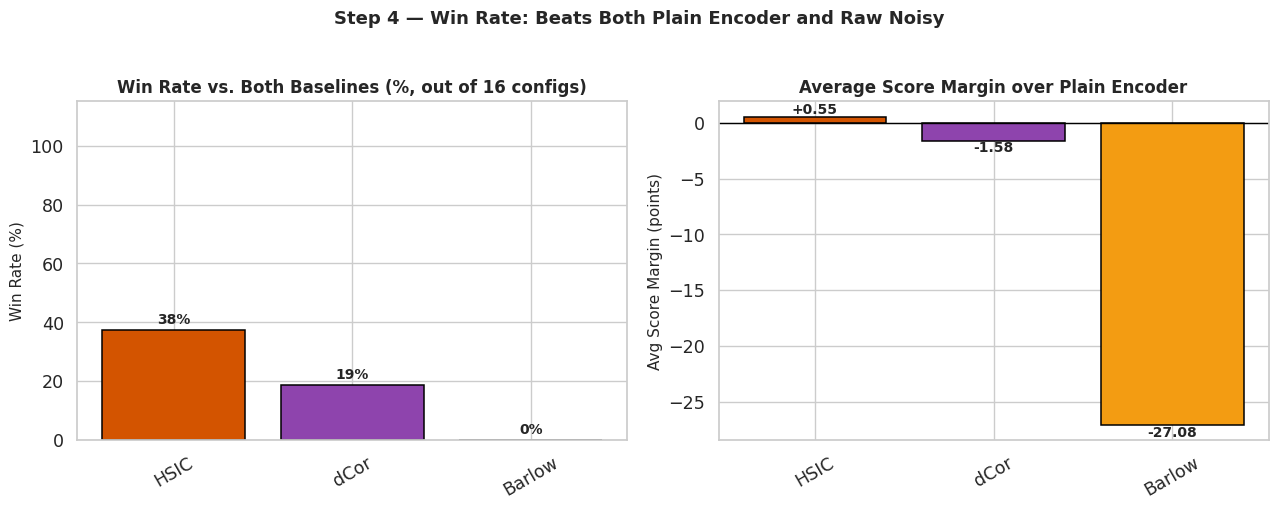

In [44]:
# ── Win rate ──────────────────────────────────────────────────────────────────
# A disentangle method "wins" a config only if it strictly beats
# BOTH the plain encoder AND raw_noisy baseline at that (dim, scale).
plain_scores    = (
    df[df["Method"] == "plain"]
    .groupby(["Dim", "Scale"])["Score"].mean()
    .rename("PlainScore")
)
rawnoisy_scores = (
    df[df["Method"] == "raw_noisy"]
    .groupby(["Dim", "Scale"])["Score"].mean()
    .rename("RawNoisyScore")
)

win_records = []
for method in DISENTANGLE_METHODS:
    m_df = df[df["Method"] == method].groupby(["Dim", "Scale"])["Score"].mean().rename("Score")
    joined = (
        m_df.to_frame()
        .join(plain_scores,    how="inner")
        .join(rawnoisy_scores, how="inner")
    )
    n_total = len(joined)
    n_win   = int(((joined["Score"] > joined["PlainScore"]) &
                   (joined["Score"] > joined["RawNoisyScore"])).sum())
    margin_plain    = float((joined["Score"] - joined["PlainScore"]).mean())
    margin_rawnoisy = float((joined["Score"] - joined["RawNoisyScore"]).mean())
    win_records.append({
        "Method":         method,
        "Label":          METHOD_LABELS[method],
        "WinRate":        n_win / n_total if n_total > 0 else 0.0,
        "AvgMarginPlain": margin_plain,
        "AvgMarginRaw":   margin_rawnoisy,
        "Wins":           n_win,
        "Total":          n_total,
    })

win_df = pd.DataFrame(win_records).sort_values("WinRate", ascending=False).reset_index(drop=True)
print("Win rate — beats BOTH plain encoder AND raw_noisy:")
print(win_df[["Label", "Wins", "Total", "WinRate", "AvgMarginPlain", "AvgMarginRaw"]].to_string(index=False))

# ── Dual bar chart: win rate + avg margin over plain ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
colors = [PALETTE.get(lbl, "#aaaaaa") for lbl in win_df["Label"]]
bars = ax.bar(win_df["Label"], win_df["WinRate"] * 100, color=colors,
              edgecolor="black", linewidth=1.1)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 1, f"{h:.0f}%",
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("Win Rate vs. Both Baselines (%, out of 16 configs)", fontsize=12, fontweight="bold")
ax.set_ylabel("Win Rate (%)", fontsize=11)
ax.set_ylim(0, 115)
ax.tick_params(axis="x", rotation=30)

ax2 = axes[1]
margin_df = win_df.sort_values("AvgMarginPlain", ascending=False)
colors2 = [PALETTE.get(lbl, "#aaaaaa") for lbl in margin_df["Label"]]
bars2 = ax2.bar(margin_df["Label"], margin_df["AvgMarginPlain"], color=colors2,
                edgecolor="black", linewidth=1.1)
for bar in bars2:
    h = bar.get_height()
    va = "bottom" if h >= 0 else "top"
    offset = 0.05 if h >= 0 else -0.05
    ax2.text(bar.get_x() + bar.get_width() / 2, h + offset, f"{h:+.2f}",
             ha="center", va=va, fontsize=10, fontweight="bold")
ax2.axhline(0, color="black", linewidth=1.0)
ax2.set_title("Average Score Margin over Plain Encoder", fontsize=12, fontweight="bold")
ax2.set_ylabel("Avg Score Margin (points)", fontsize=11)
ax2.tick_params(axis="x", rotation=30)

plt.suptitle("Step 4 — Win Rate: Beats Both Plain Encoder and Raw Noisy",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()

if SAVE_FIGURES:
    out = FIGURE_OUT_DIR / "step4_win_rate.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"[INFO] Saved: {out}")
plt.show()


## Step 5 — Score heatmap

Full breakdown of each method's normalized score across all (dim, scale) pairs.  
Allows visual inspection of where each method is strong or weak.

[INFO] Saved: /home/wyuhan/projects/robust-offline-rl-disentanglement/results/method_selection/figures/ant-medium-v2/step5_score_heatmap.png


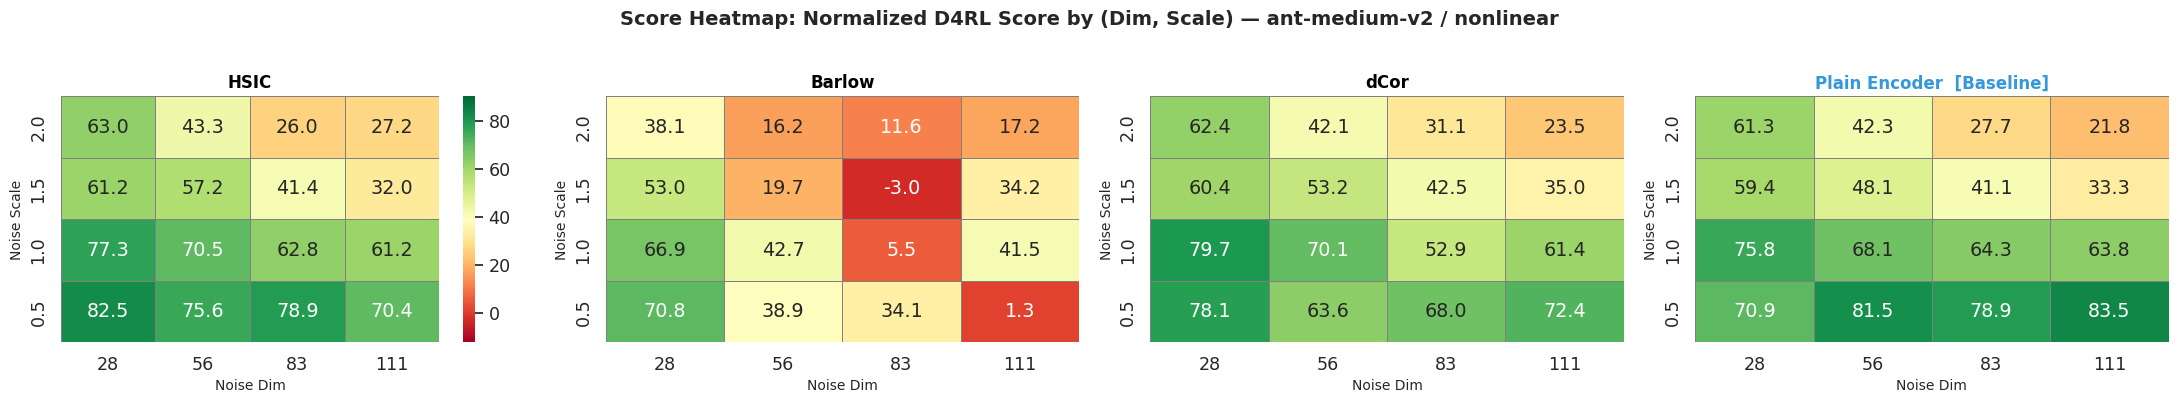

In [45]:
# ── Heatmaps: disentangle methods + plain baseline ────────────────────────────
methods_to_plot = DISENTANGLE_METHODS + ["plain"]
n_methods = len(methods_to_plot)
ncols = 4
nrows = (n_methods + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4 * nrows))
axes = np.array(axes).flatten()

vmin = df["Score"].min()
vmax = df["Score"].max()

for i, method in enumerate(methods_to_plot):
    m_df = df[df["Method"] == method]
    pivot = m_df.pivot_table(index="Scale", columns="Dim", values="Score", aggfunc="mean")
    pivot = pivot.sort_index(ascending=False)  # high scale at top

    label = METHOD_LABELS.get(method, method)
    ax = axes[i]
    sns.heatmap(
        pivot, ax=ax, annot=True, fmt=".1f", cmap="RdYlGn",
        vmin=vmin, vmax=vmax, linewidths=0.5, linecolor="grey",
        cbar=(i == 0),
    )
    is_plain = method == "plain"
    title_suffix = "  [Baseline]" if is_plain else ""
    ax.set_title(f"{label}{title_suffix}",
                 fontsize=12, fontweight="bold",
                 color="#3498db" if is_plain else "black")
    ax.set_xlabel("Noise Dim", fontsize=10)
    ax.set_ylabel("Noise Scale", fontsize=10)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    f"Score Heatmap: Normalized D4RL Score by (Dim, Scale) — {TARGET_ENV} / {TARGET_TYPE}",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()

if SAVE_FIGURES:
    out = FIGURE_OUT_DIR / "step5_score_heatmap.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"[INFO] Saved: {out}")
plt.show()

## Step 6 — Composite ranking and final verdict

Aggregate the four metrics into a single composite score using **normalized ranks**:

| Metric | Weight | Direction |
|--------|--------|-----------|
| Global mean | 0.30 | higher is better |
| Hard-condition mean | 0.35 | higher is better |
| Degradation drop % | 0.20 | lower is better |
| Win rate vs. plain | 0.15 | higher is better |

Hard-condition mean is weighted highest because this setting best distinguishes methods that
truly disentangle from those that only improve marginally.

In [46]:
# ── Build composite ranking ──────────────────────────────────────────────────
# All four metrics are expressed as percentages so the composite is dimensionally uniform:
#   Global Mean %  — (mean D4RL score / oracle_mean) × 100
#   Hard Mean %    — (hard-condition score / oracle_mean) × 100
#   Retention      — 100 − Drop%
#   Win Rate       — for disentangle methods: % configs beating BOTH plain AND raw_noisy
#                  — for plain/raw_noisy:     % configs beating ALL disentangle methods (†)

WEIGHTS = {
    "GlobalMean_pct": 0.30,
    "HardMean_pct":   0.35,
    "Retention":      0.20,
    "WinRate":        0.15,
}

# ── Disentangle methods composite ────────────────────────────────────────────
comp = (
    global_mean[global_mean["Method"].isin(DISENTANGLE_METHODS)][["Method", "Label", "GlobalMean"]]
    .merge(hard_mean[["Method", "HardMean"]], on="Method", how="inner")
    .merge(drop_df[["Method", "DropPct"]], on="Method", how="inner")
    .merge(win_df[["Method", "WinRate"]], on="Method", how="inner")
)
comp["GlobalMean_pct"] = comp["GlobalMean"] / oracle_mean * 100
comp["HardMean_pct"]   = comp["HardMean"]   / oracle_mean * 100
comp["Retention"]      = (100 - comp["DropPct"]).clip(0, 100)
comp["WinRate"]        = (comp["WinRate"] * 100).clip(0, 100)
comp["Composite"] = (
    WEIGHTS["GlobalMean_pct"] * comp["GlobalMean_pct"]
    + WEIGHTS["HardMean_pct"]   * comp["HardMean_pct"]
    + WEIGHTS["Retention"]      * comp["Retention"]
    + WEIGHTS["WinRate"]        * comp["WinRate"]
)
comp = comp.sort_values("Composite", ascending=False).reset_index(drop=True)
comp["Rank"] = range(1, len(comp) + 1)

# ── Baseline win rate: wins when beating ALL disentangle methods at a config ──
def baseline_win_rate(baseline_method, disentangle_methods, df):
    """Fraction of (dim, scale) configs where baseline beats every disentangle method."""
    base = df[df["Method"] == baseline_method].groupby(["Dim", "Scale"])["Score"].mean()
    wins, total = 0, 0
    for (dim, scale), base_score in base.items():
        disent_scores = [
            df[(df["Method"] == m) & (df["Dim"] == dim) & (df["Scale"] == scale)]["Score"].mean()
            for m in disentangle_methods
            if len(df[(df["Method"] == m) & (df["Dim"] == dim) & (df["Scale"] == scale)]) > 0
        ]
        if disent_scores:
            total += 1
            if all(base_score > s for s in disent_scores):
                wins += 1
    rate = wins / total * 100 if total > 0 else float("nan")
    return rate, wins, total

# ── Baseline composite rows ───────────────────────────────────────────────────
baseline_comp_rows = []
for method, label in [("plain", "Plain Encoder"), ("raw_noisy", "Raw Noisy")]:
    gm = float(global_mean.loc[global_mean["Method"] == method, "GlobalMean"].iloc[0]) \
         if method in global_mean["Method"].values else float("nan")
    hm = float(hard_mean.loc[hard_mean["Method"] == method, "HardMean"].iloc[0]) \
         if method in hard_mean["Method"].values else float("nan")
    dp = float(drop_df.loc[drop_df["Method"] == method, "DropPct"].iloc[0]) \
         if method in drop_df["Method"].values else float("nan")
    wr_pct, wins, total = baseline_win_rate(method, DISENTANGLE_METHODS, df)
    gm_pct    = gm / oracle_mean * 100
    hm_pct    = hm / oracle_mean * 100
    retention = 100 - dp
    composite = (
        WEIGHTS["GlobalMean_pct"] * gm_pct
        + WEIGHTS["HardMean_pct"]   * hm_pct
        + WEIGHTS["Retention"]      * retention
        + WEIGHTS["WinRate"]        * wr_pct
    )
    baseline_comp_rows.append({
        "Method": method, "Label": label,
        "GlobalMean": gm, "HardMean": hm, "DropPct": dp,
        "GlobalMean_pct": gm_pct, "HardMean_pct": hm_pct,
        "Retention": retention, "WinRate": wr_pct,
        "Composite": composite, "Wins": wins, "Total": total,
    })
baseline_comp_df = pd.DataFrame(baseline_comp_rows)

# ── Unified display table ─────────────────────────────────────────────────────
disent_disp = comp[["Rank", "Label", "GlobalMean_pct", "HardMean_pct",
                     "Retention", "WinRate", "Composite"]].copy()
disent_disp.columns = ["Rank", "Method", "Global Mean (%)", "Hard Mean (%)",
                        "Retention (%)", "Win Rate (%)", "Composite"]

base_disp = baseline_comp_df[["Label", "GlobalMean_pct", "HardMean_pct",
                                "Retention", "WinRate", "Composite"]].copy()
base_disp.columns = ["Method", "Global Mean (%)", "Hard Mean (%)",
                      "Retention (%)", "Win Rate (%)", "Composite"]
base_disp.insert(0, "Rank", "—")

comp_all = pd.concat([disent_disp, base_disp], ignore_index=True)

print(f"[INFO] Oracle mean used as denominator: {oracle_mean:.3f}")
print("\nComposite ranking (all metrics as %):")
print(comp_all.to_string(index=False, float_format=lambda x: f"{x:.1f}" if isinstance(x, float) else x))
print("\n† Win Rate for Plain/Raw Noisy = % configs where baseline beats ALL disentangle methods.")

if SAVE_TABLES:
    out = TABLE_OUT_DIR / "composite_ranking.csv"
    comp_all.to_csv(out, index=False)
    print(f"[INFO] Saved: {out}")


[INFO] Oracle mean used as denominator: 83.883

Composite ranking (all metrics as %):
Rank        Method  Global Mean (%)  Hard Mean (%)  Retention (%)  Win Rate (%)  Composite
   1          HSIC             69.3           37.7           51.9          37.5       50.0
   2          dCor             66.8           39.4           56.4          18.8       47.9
   3        Barlow             36.4           17.9           57.3           0.0       28.6
   — Plain Encoder             68.7           36.9           48.6          25.0       47.0
   —     Raw Noisy             72.9           48.2           55.3          56.2       58.3

† Win Rate for Plain/Raw Noisy = % configs where baseline beats ALL disentangle methods.
[INFO] Saved: /home/wyuhan/projects/robust-offline-rl-disentanglement/results/method_selection/tables/ant-medium-v2/composite_ranking.csv


[INFO] Saved: /home/wyuhan/projects/robust-offline-rl-disentanglement/results/method_selection/figures/ant-medium-v2/step6_composite_ranking.png


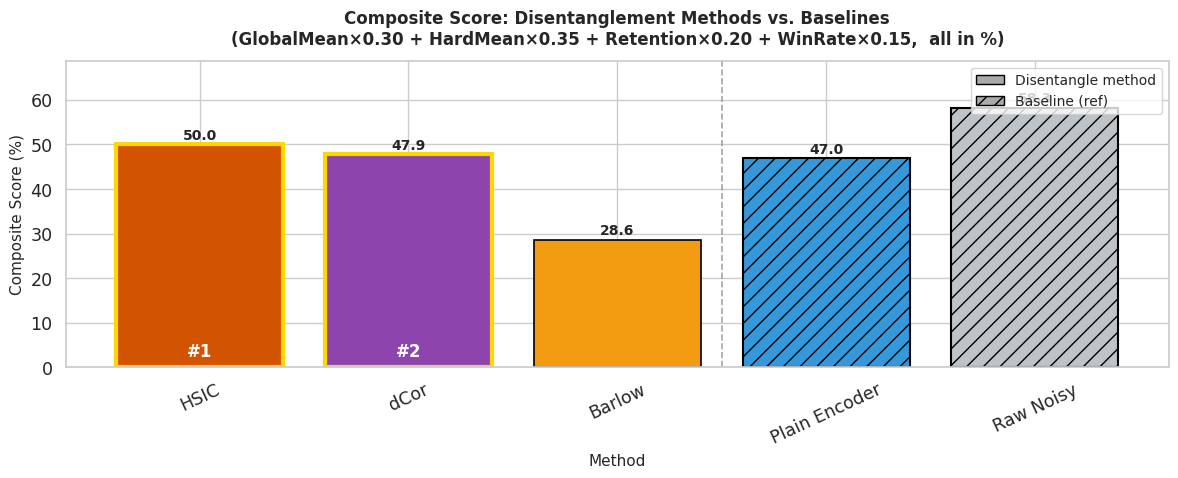

In [47]:
# ── Composite score bar chart (all methods + baselines) ──────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

all_labels    = list(comp["Label"]) + list(baseline_comp_df["Label"])
all_composite = list(comp["Composite"]) + list(baseline_comp_df["Composite"])
is_baseline   = [False] * len(comp) + [True] * len(baseline_comp_df)

colors = [PALETTE.get(lbl, "#aaaaaa") for lbl in all_labels]
bars = ax.bar(all_labels, all_composite, color=colors,
              edgecolor="black", linewidth=1.2)

# Style baseline bars with hatching
for bar, baseline in zip(bars, is_baseline):
    if baseline:
        bar.set_hatch("//")
        bar.set_linewidth(1.5)

# Annotate values
for bar, composite, baseline in zip(bars, all_composite, is_baseline):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.4,
            f"{h:.1f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

# Gold border for top-2 disentangle methods
for i, (bar, row) in enumerate(zip(bars[:len(comp)], comp.itertuples())):
    if row.Rank <= 2:
        bar.set_linewidth(3)
        bar.set_edgecolor("gold")
        ax.text(bar.get_x() + bar.get_width() / 2, 1.5,
                f"#{row.Rank}", ha="center", va="bottom", fontsize=12,
                fontweight="bold", color="white")

# Vertical separator between disentangle and baselines
ax.axvline(len(comp) - 0.5, color="gray", linestyle="--", linewidth=1.2, alpha=0.7)

ax.set_title(
    "Composite Score: Disentanglement Methods vs. Baselines\n"
    "(GlobalMean×0.30 + HardMean×0.35 + Retention×0.20 + WinRate×0.15,  all in %)",
    fontsize=12, fontweight="bold", pad=12,
)
ax.set_ylabel("Composite Score (%)", fontsize=11)
ax.set_xlabel("Method", fontsize=11)
ax.tick_params(axis="x", rotation=25)
ymax = max(all_composite)
ax.set_ylim(0, ymax * 1.18)

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="#aaaaaa", edgecolor="black", label="Disentangle method"),
    Patch(facecolor="#aaaaaa", edgecolor="black", hatch="//", label="Baseline (ref)"),
]
ax.legend(handles=legend_handles, fontsize=10, loc="upper right")

plt.tight_layout()

if SAVE_FIGURES:
    out = FIGURE_OUT_DIR / "step6_composite_ranking.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"[INFO] Saved: {out}")
plt.show()


[INFO] Saved: /home/wyuhan/projects/robust-offline-rl-disentanglement/results/method_selection/figures/ant-medium-v2/step6_radar_chart.png


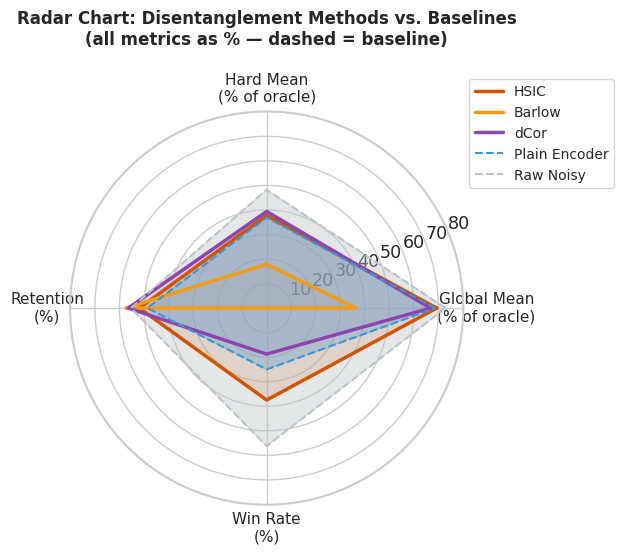

In [48]:
# ── Radar chart: all methods + both baselines ────────────────────────────────
# All four axes are percentages:
#   Global Mean %  — (mean D4RL score / oracle_mean) × 100
#   Hard Mean %    — (hard-condition score / oracle_mean) × 100
#   Retention      — 100 − Drop%
#   Win Rate       — disentangle methods: % configs beating BOTH plain AND raw_noisy
#                  — plain/raw_noisy:     % configs beating ALL disentangle methods
radar_methods = DISENTANGLE_METHODS + ["plain", "raw_noisy"]

# Pre-compute baseline win rates for radar
_plain_wr,    _, _ = baseline_win_rate("plain",     DISENTANGLE_METHODS, df)
_rawnoisy_wr, _, _ = baseline_win_rate("raw_noisy", DISENTANGLE_METHODS, df)
_baseline_wr = {"plain": _plain_wr, "raw_noisy": _rawnoisy_wr}

def get_radar_values(method):
    gm = float(global_mean.loc[global_mean["Method"] == method, "GlobalMean"].iloc[0]) \
         if method in global_mean["Method"].values else 0.0
    hm = float(hard_mean.loc[hard_mean["Method"] == method, "HardMean"].iloc[0]) \
         if method in hard_mean["Method"].values else 0.0
    dp = float(drop_df.loc[drop_df["Method"] == method, "DropPct"].iloc[0]) \
         if method in drop_df["Method"].values else 100.0
    if method in _baseline_wr:
        wr = _baseline_wr[method]
    else:
        wr = float(win_df.loc[win_df["Method"] == method, "WinRate"].iloc[0]) * 100 \
             if method in win_df["Method"].values else 0.0
    return [
        gm / oracle_mean * 100,
        hm / oracle_mean * 100,
        max(0.0, 100 - dp),
        wr,
    ]

labels = ["Global Mean\n(% of oracle)", "Hard Mean\n(% of oracle)", "Retention\n(%)", "Win Rate\n(%)"]
N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

all_vals = [v for m in radar_methods for v in get_radar_values(m)]
ylim_max = min(105, max(all_vals) * 1.10)

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for method in radar_methods:
    lbl = METHOD_LABELS.get(method, method)
    is_baseline = method in ("plain", "raw_noisy")
    values = get_radar_values(method) + [get_radar_values(method)[0]]
    color = PALETTE.get(lbl, "#aaaaaa")
    ax.plot(angles, values,
            linewidth=1.5 if is_baseline else 2.5,
            linestyle="--" if is_baseline else "-",
            label=lbl, color=color)
    ax.fill(angles, values,
            alpha=0.4 if is_baseline else 0.20,
            color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, ylim_max)
ax.set_title(
    "Radar Chart: Disentanglement Methods vs. Baselines\n"
    "(all metrics as % — dashed = baseline)",
    fontsize=12, fontweight="bold", pad=20,
)
ax.legend(loc="upper right", bbox_to_anchor=(1.40, 1.1), fontsize=10)
plt.tight_layout()

if SAVE_FIGURES:
    out = FIGURE_OUT_DIR / "step6_radar_chart.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"[INFO] Saved: {out}")
plt.show()


In [49]:
# ── Final verdict ─────────────────────────────────────────────────────────────
top2 = comp.head(2)
n_configs = len(TARGET_DIMS) * len(TARGET_SCALES)
print("=" * 60)
print("FINAL VERDICT — Top-2 Disentanglement Methods")
print(f"Environment : {TARGET_ENV}")
print(f"Noise type  : {TARGET_TYPE}")
print(f"Oracle ref  : {oracle_mean:.3f}")
print("=" * 60)
for _, row in top2.iterrows():
    wins = int(row["WinRate"] / 100 * n_configs)
    print(f"\n#{int(row['Rank'])}  {row['Label']}  (method key: {row['Method']})")
    print(f"    Global Mean    : {row['GlobalMean']:.3f}  →  {row['GlobalMean_pct']:.1f}% of oracle")
    print(f"    Hard Mean      : {row['HardMean']:.3f}  →  {row['HardMean_pct']:.1f}% of oracle")
    print(f"    Retention      : {row['Retention']:.1f}%  (score drop: {row['DropPct']:.1f}%)")
    print(f"    Win Rate       : {row['WinRate']:.1f}%  ({wins}/{n_configs} configs)")
    print(f"    Composite      : {row['Composite']:.2f}%")

print("\n" + "=" * 60)
plain_global = float(global_mean.loc[global_mean["Method"] == "plain", "GlobalMean"].iloc[0]) \
    if "plain" in global_mean["Method"].values else float("nan")
print(f"Oracle (no noise) : {oracle_mean:.3f}  (100.0% reference)")
print(f"Plain encoder     : {plain_global:.3f}  ({plain_global / oracle_mean * 100:.1f}% of oracle)")
print("=" * 60)


FINAL VERDICT — Top-2 Disentanglement Methods
Environment : ant-medium-v2
Noise type  : nonlinear
Oracle ref  : 83.883

#1  HSIC  (method key: disentangled_hsic)
    Global Mean    : 58.159  →  69.3% of oracle
    Hard Mean      : 31.665  →  37.7% of oracle
    Retention      : 51.9%  (score drop: 48.1%)
    Win Rate       : 37.5%  (6/16 configs)
    Composite      : 50.02%

#2  dCor  (method key: disentangled_dcor)
    Global Mean    : 56.029  →  66.8% of oracle
    Hard Mean      : 33.032  →  39.4% of oracle
    Retention      : 56.4%  (score drop: 43.6%)
    Win Rate       : 18.8%  (3/16 configs)
    Composite      : 47.91%

Oracle (no noise) : 83.883  (100.0% reference)
Plain encoder     : 57.612  (68.7% of oracle)
